<a href="https://colab.research.google.com/github/dhanushkaputty/DL/blob/main/Convulational6dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
dataset_path = r"C:\Users\dhanu\Downloads\kagglecatsanddogs_5340\PetImages"

In [ ]:
import os

print(os.path.exists("C:/Users/dhanu/Downloads/kagglecatsanddogs_5340/PetImages"))

False


In [ ]:
from tensorflow.keras.datasets import cifar10
import tensorflow as tf
from tensorflow.keras import layers, models

# Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')   # 10 classes
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 49ms/step - accuracy: 0.3969 - loss: 1.6312 - val_accuracy: 0.5102 - val_loss: 1.3414
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.5483 - loss: 1.2661 - val_accuracy: 0.6192 - val_loss: 1.0876
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - accuracy: 0.6100 - loss: 1.1036 - val_accuracy: 0.6640 - val_loss: 0.9700
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.6518 - loss: 0.9970 - val_accuracy: 0.6557 - val_loss: 0.9856
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.6809 - loss: 0.9217 - val_accuracy: 0.6859 - val_loss: 0.8925
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 51ms/step - accuracy: 0.7062 - loss: 0.8531 - val_accuracy: 0.6913 - val_loss: 0.8837
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.7242 - loss: 0.7966 - val_accuracy: 0.7150 - val_loss: 0.8277
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.7389 -

In [ ]:
# Predict on test data
y_pred = model.predict(X_test)

# Convert probabilities → class labels
y_pred_classes = y_pred.argmax(axis=1)

# Flatten actual labels
y_test_classes = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
accuracy = accuracy_score(y_test_classes, y_pred_classes)
print("Accuracy (sklearn):", accuracy)

Accuracy (sklearn): 0.726


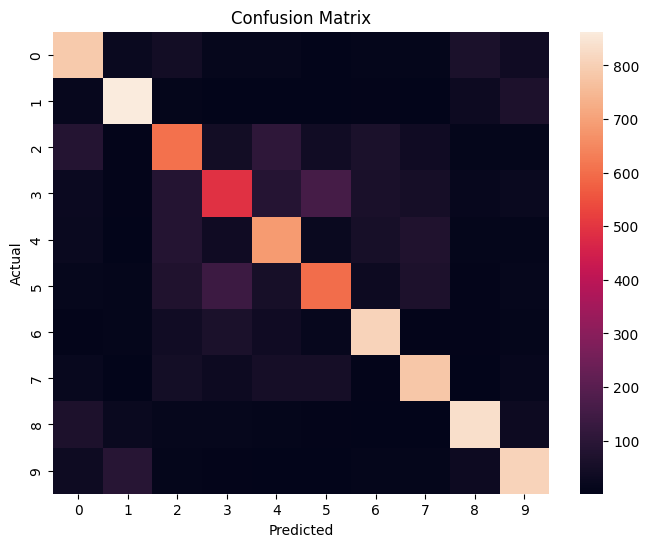

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(classification_report(y_test_classes, y_pred_classes))

              precision    recall  f1-score   support

           0       0.73      0.79      0.76      1000
           1       0.83      0.86      0.85      1000
           2       0.60      0.60      0.60      1000
           3       0.59      0.49      0.53      1000
           4       0.66      0.69      0.67      1000
           5       0.66      0.60      0.63      1000
           6       0.77      0.81      0.79      1000
           7       0.75      0.78      0.77      1000
           8       0.83      0.84      0.83      1000
           9       0.80      0.81      0.80      1000

    accuracy                           0.73     10000
   macro avg       0.72      0.73      0.72     10000
weighted avg       0.72      0.73      0.72     10000



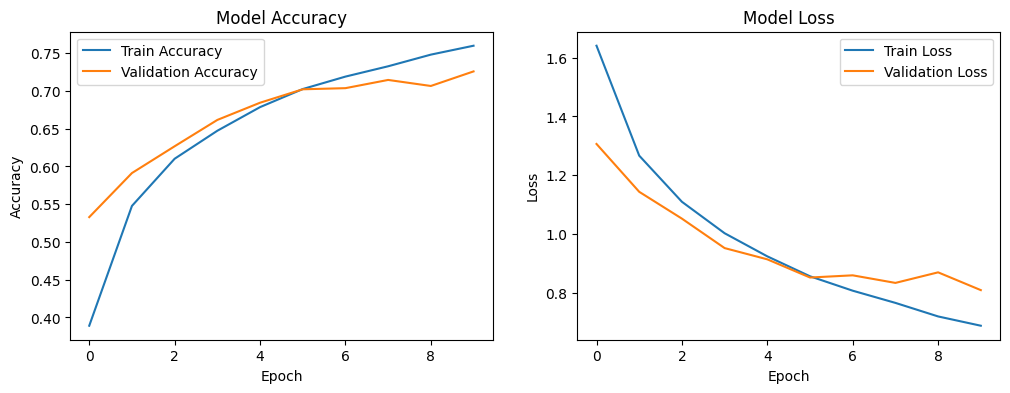

In [ ]:
plt.figure(figsize=(12,4))

# Accuracy Graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

tuned cnn..data augmentation,dropout,batch normalization

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True
)
datagen.fit(X_train)

model2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_test, y_test)
)

print("Tuned Model Accuracy:", model2.evaluate(X_test, y_test)[1])

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 122s 77ms/step - accuracy: 0.3947 - loss: 1.6789 - val_accuracy: 0.3748 - val_loss: 2.1294
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 113s 73ms/step - accuracy: 0.5219 - loss: 1.3331 - val_accuracy: 0.5995 - val_loss: 1.1438
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 108s 69ms/step - accuracy: 0.5953 - loss: 1.1667 - val_accuracy: 0.5791 - val_loss: 1.2144
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 107s 68ms/step - accuracy: 0.6302 - loss: 1.0679 - val_accuracy: 0.6474 - val_loss: 0.9869
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 108s 69ms/step - accuracy: 0.6577 - loss: 0.9957 - val_accuracy: 0.7055 - val_loss: 0.8644
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 108s 69ms/step - accuracy: 0.6795 - loss: 0.9395 - val_accuracy: 0.7218 - val_loss: 0.8332
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 111s 71ms/step - accuracy: 0.6958 - loss: 0.8949 - val_accuracy: 0.7328 - val_loss: 0.8112
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 118s 75ms/step - accuracy: 

In [ ]:
model3 = models.Sequential([
    layers.Conv2D(96, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(384, (3,3), padding='same', activation='relu'),
    layers.Conv2D(384, (3,3), padding='same', activation='relu'),
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),

    layers.Flatten(),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

model3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)


NameError: name 'models' is not defined

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history1.history['val_accuracy'], label='Baseline')
plt.plot(history2.history['val_accuracy'], label='Tuned CNN')
plt.plot(history3.history['val_accuracy'], label='AlexNet')

plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
results = {}

configs = [
    {"name": "Baseline", "filters":32, "dropout":0.0, "lr":0.001},
    {"name": "With Dropout", "filters":32, "dropout":0.5, "lr":0.001},
    {"name": "More Filters", "filters":64, "dropout":0.5, "lr":0.001},
    {"name": "Low LR", "filters":32, "dropout":0.5, "lr":0.0001},
    {"name": "High LR", "filters":32, "dropout":0.5, "lr":0.01}
]

for config in configs:
    print(f"\nTraining: {config['name']}")

    model = build_model(
        filters=config["filters"],
        dropout_rate=config["dropout"],
        lr=config["lr"]
    )

    history = model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=1
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    results[config["name"]] = acc

In [ ]:
print("\nFinal Results:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

In [ ]:
plt.bar(results.keys(), results.values())
plt.xticks(rotation=30)
plt.title("Parameter Comparison")
plt.ylabel("Accuracy")
plt.show()

tuned cnn..data augmentation,dropout,batch normalization